Seleção de colunas e PCA

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("./raw/dataset_merged_binary.csv", parse_dates=["date"])

cols = ["date", "credit_spread", "industrial_production", "price_index",
        "real_interest", "volatility_index", "yield_curve_slope", "target_12m"]

df = df[cols].dropna().reset_index(drop=True)

features = ["credit_spread", "industrial_production", "price_index",
            "real_interest", "volatility_index", "yield_curve_slope"]

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2","pca_3"])
df_pca = pd.concat(
    [df_pca, df[["date", "target_12m"]].reset_index(drop=True)],
    axis=1
)

variancia_explicada = pca.explained_variance_ratio_
variacia_total = variancia_explicada.sum()

print(f"Variancia explicada pela PC1: {variancia_explicada[0]:.2%}")
print(f"Variancia explicada pela PC2: {variancia_explicada[1]:.2%}")
print(f"Variancia explicada pela PC3: {variancia_explicada[2]:.2%}")

print(f"Variância total explicada pelos três componentes: {variacia_total:.2%}")

Variancia explicada pela PC1: 44.70%
Variancia explicada pela PC2: 30.59%
Variancia explicada pela PC3: 15.77%
Variância total explicada pelos três componentes: 91.06%


Matriz de Correlação

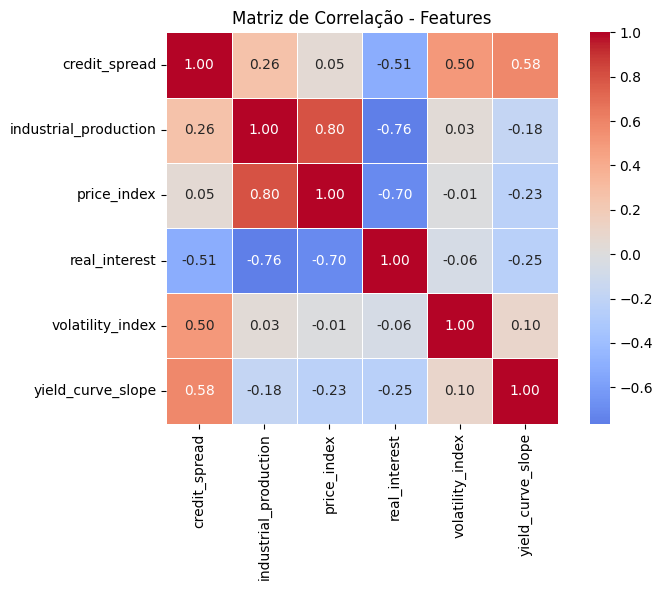

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlação - Features")
plt.tight_layout()
plt.show()

Divisão entre treino e teste

In [28]:
from sklearn.model_selection import train_test_split

df = df.sort_values("date").reset_index(drop=True)
df_pca = df_pca.sort_values("date").reset_index(drop=True)

X_no_pca = df[features]
X_pca_features = df_pca[["pca_1", "pca_2", "pca_3"]]
y = df["target_12m"]

X_train_no_pca, X_test_no_pca, y_train_no_pca, y_test_no_pca = train_test_split(
    X_no_pca,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_features,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y
)

O shuffle=True embaralha os dados antes da divisão, evitando que treino e teste fiquem em períodos econômicos completamente distintos, o que causava desbalanceamento severo nas classes. O stratify=y garante que a proporção entre "Normal" e "Crise" seja mantida em ambos os conjuntos.

Função base de treino, teste e plot dos modelos

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd

LABELS = ["Normal", "Crise"]
ALL_CLASSES = [0, 1]

resultados = []

def avaliar_modelo(model, X_train, X_test, y_train, y_test, nome_modelo="Modelo"):

    print(f"\n===== {nome_modelo} =====")

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\n--- TREINO ---")
    print(classification_report(y_train, y_pred_train, labels=ALL_CLASSES, target_names=LABELS, zero_division=0))

    print("\n--- TESTE ---")
    print(classification_report(y_test, y_pred_test, labels=ALL_CLASSES, target_names=LABELS, zero_division=0))

    # ===== ACUMULA RESULTADOS =====
    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, average="macro", labels=ALL_CLASSES, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, average="macro", labels=ALL_CLASSES, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_test, average="macro", labels=ALL_CLASSES, zero_division=0),
    })

    # ===== MATRIZES LADO A LADO =====
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cm_train = confusion_matrix(y_train, y_pred_train, labels=ALL_CLASSES)
    ConfusionMatrixDisplay(cm_train, display_labels=LABELS).plot(ax=axes[0], xticks_rotation=45)
    axes[0].set_title(f"{nome_modelo} - Matriz de Confusão (Treino)")

    cm_test = confusion_matrix(y_test, y_pred_test, labels=ALL_CLASSES)
    ConfusionMatrixDisplay(cm_test, display_labels=LABELS).plot(ax=axes[1], xticks_rotation=45)
    axes[1].set_title(f"{nome_modelo} - Matriz de Confusão (Teste)")

    plt.tight_layout()
    plt.show()

Árvore de Decisão

Melhores parâmetros (sem PCA):
{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}

===== Decision Tree (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       166
       Crise       0.99      0.93      0.96       138

    accuracy                           0.97       304
   macro avg       0.97      0.96      0.97       304
weighted avg       0.97      0.97      0.97       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.91      0.99      0.95        72
       Crise       0.98      0.88      0.93        59

    accuracy                           0.94       131
   macro avg       0.95      0.93      0.94       131
weighted avg       0.94      0.94      0.94       131



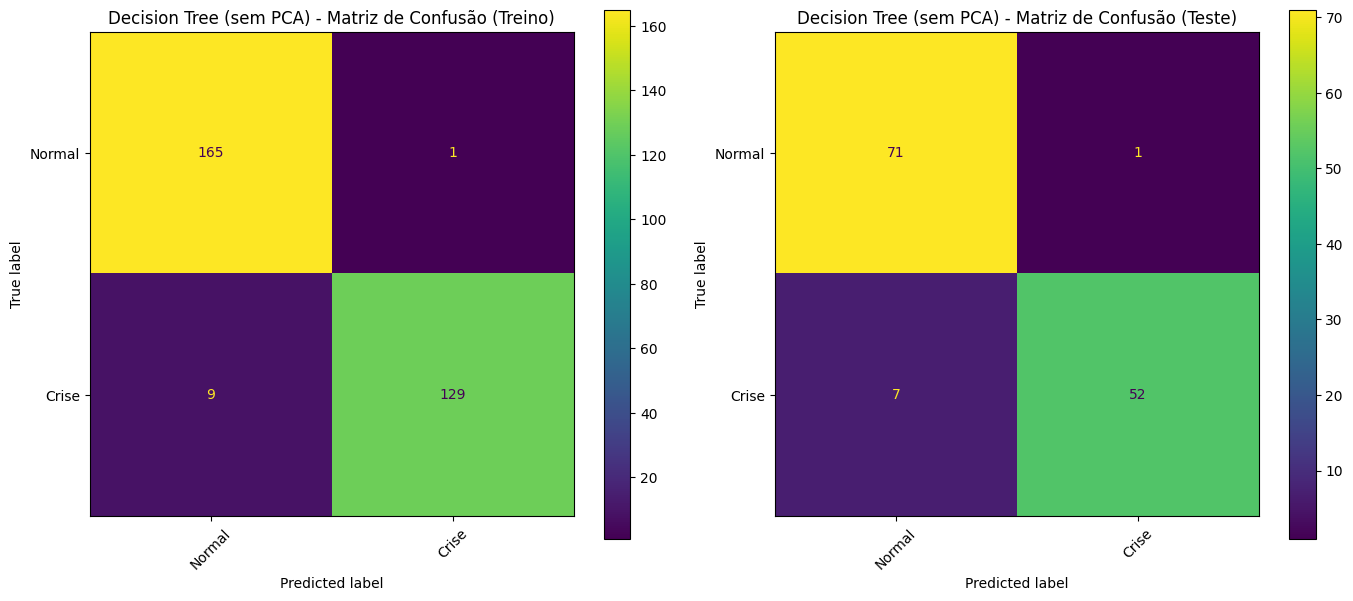

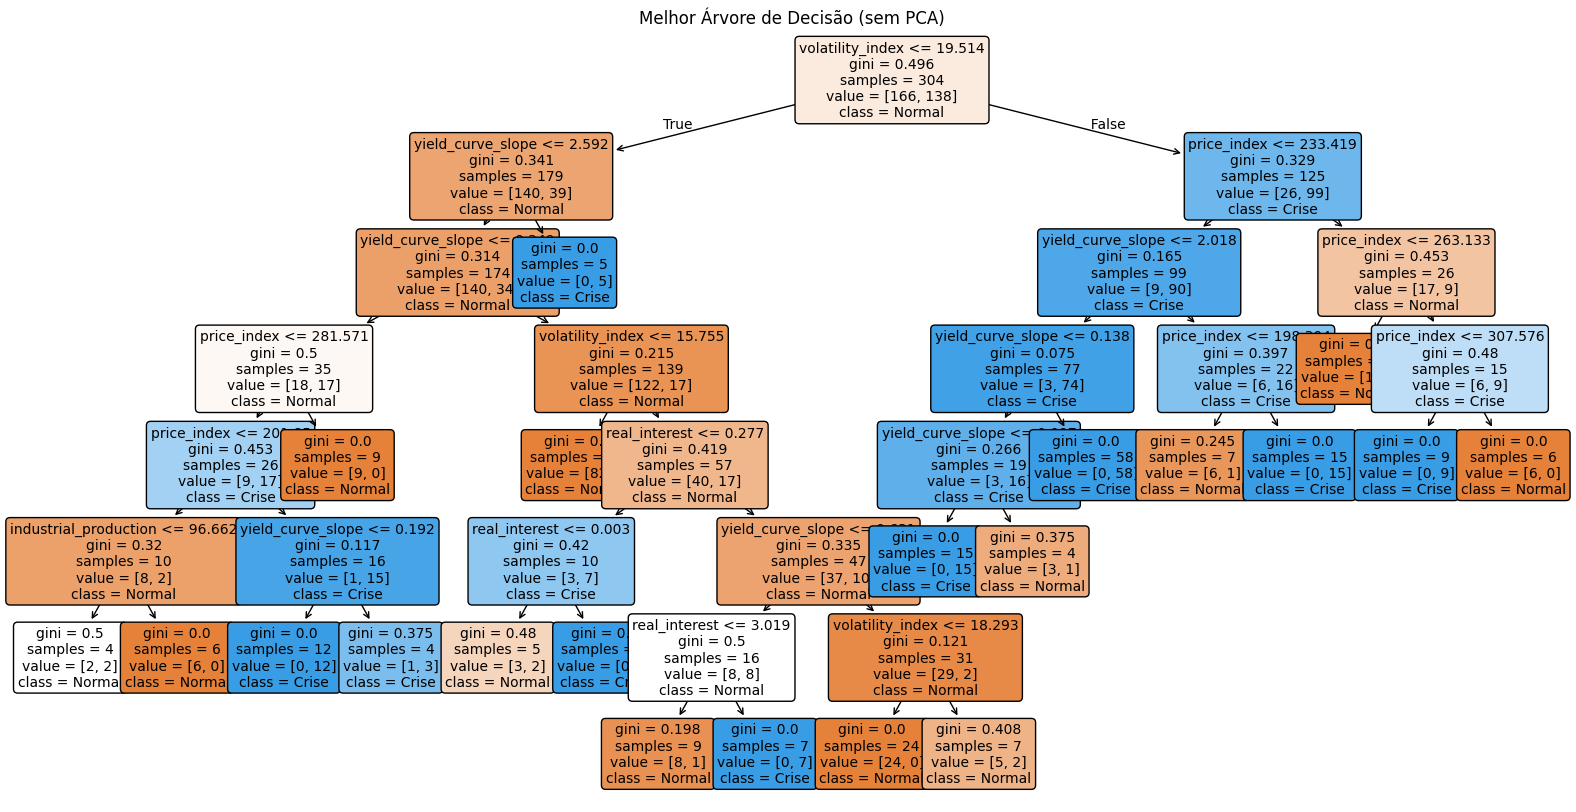

Melhores parâmetros (PCA):
{'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}

===== Decision Tree (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.92      0.99      0.95       166
       Crise       0.99      0.89      0.94       138

    accuracy                           0.95       304
   macro avg       0.95      0.94      0.95       304
weighted avg       0.95      0.95      0.95       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.75      0.81      0.78        72
       Crise       0.74      0.68      0.71        59

    accuracy                           0.75       131
   macro avg       0.75      0.74      0.74       131
weighted avg       0.75      0.75      0.75       131



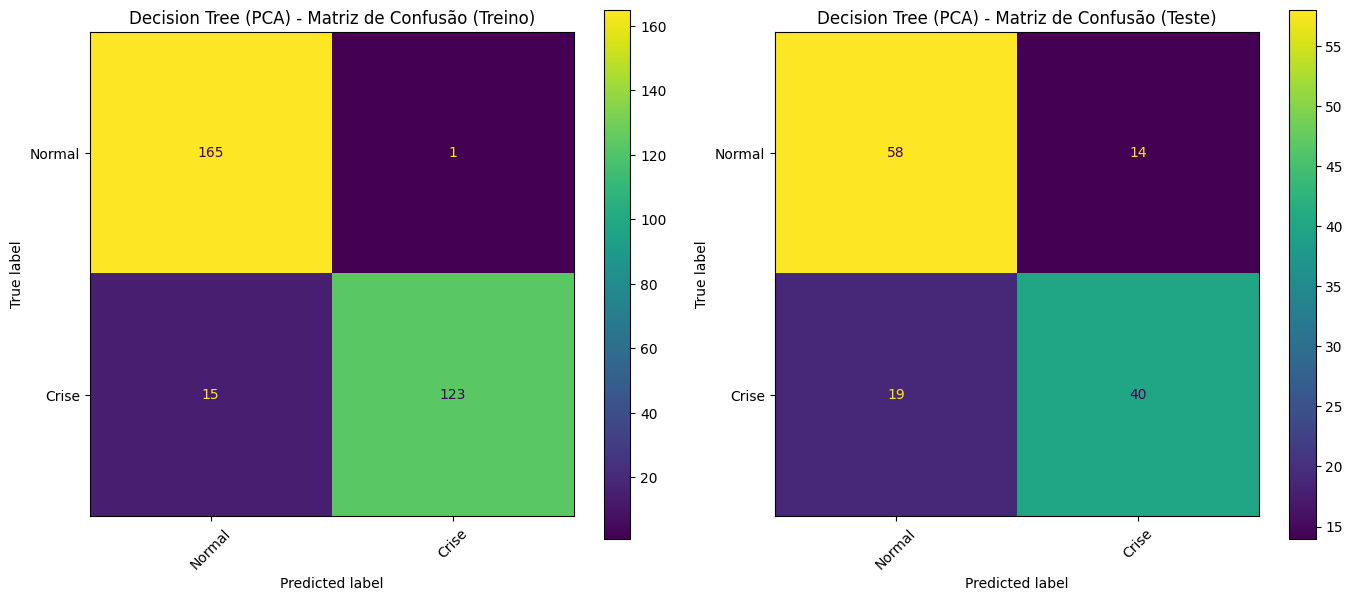

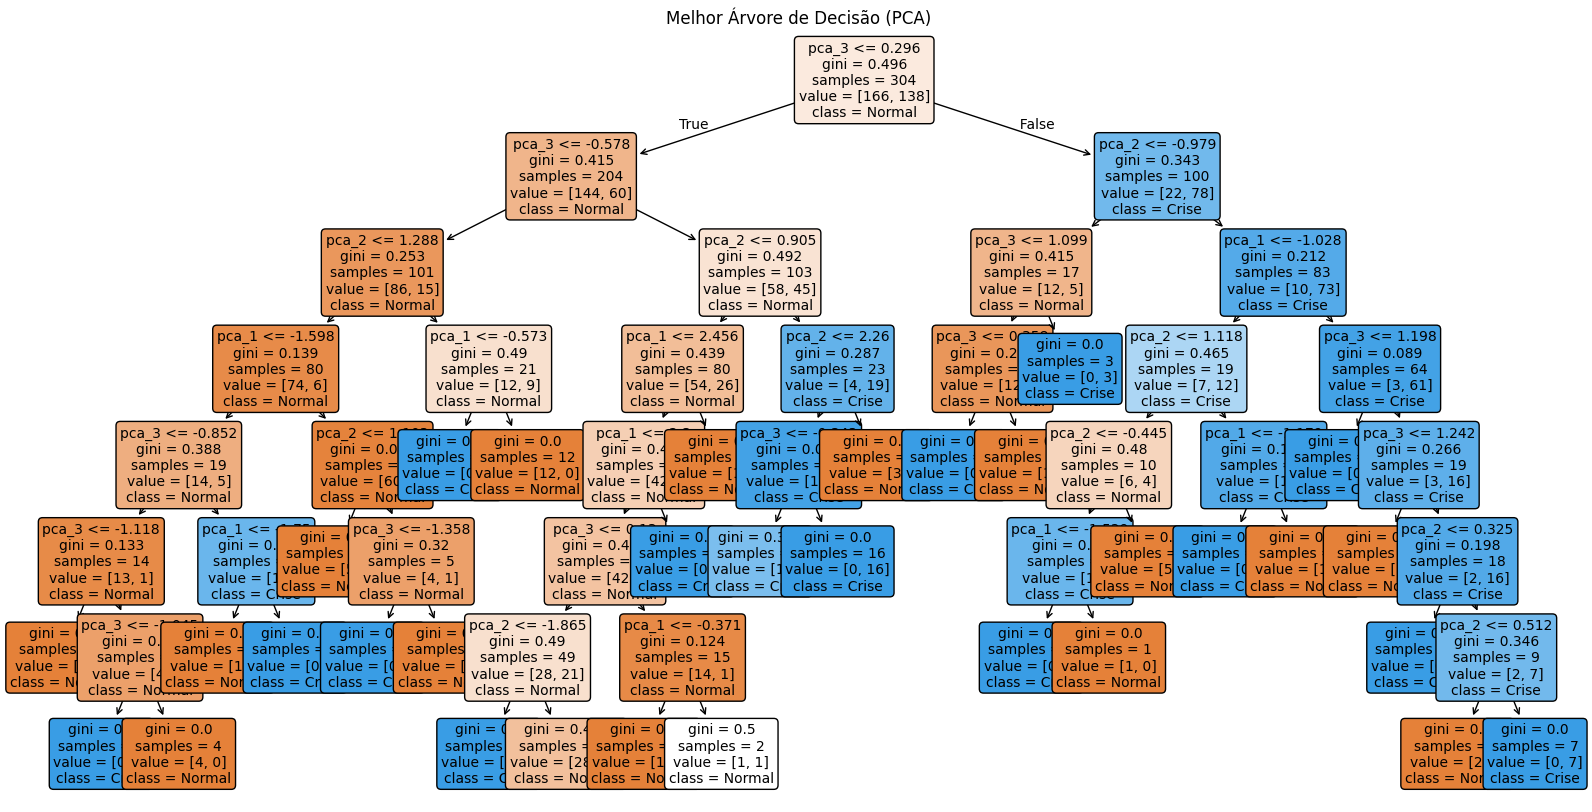

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# ===== MODELO BASE =====
tree = DecisionTreeClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_tree_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_tree_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Decision Tree (sem PCA)"
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_no_pca,
    feature_names=features,
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (sem PCA)")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_tree_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_tree_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Decision Tree (PCA)"
)

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree_pca,
    feature_names=["pca_1", "pca_2", "pca_3"],
    class_names=LABELS,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (PCA)")
plt.show()

KNN

Melhores parâmetros (sem PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}

===== KNN (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       166
       Crise       1.00      1.00      1.00       138

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96        72
       Crise       0.96      0.93      0.95        59

    accuracy                           0.95       131
   macro avg       0.96      0.95      0.95       131
weighted avg       0.95      0.95      0.95       131



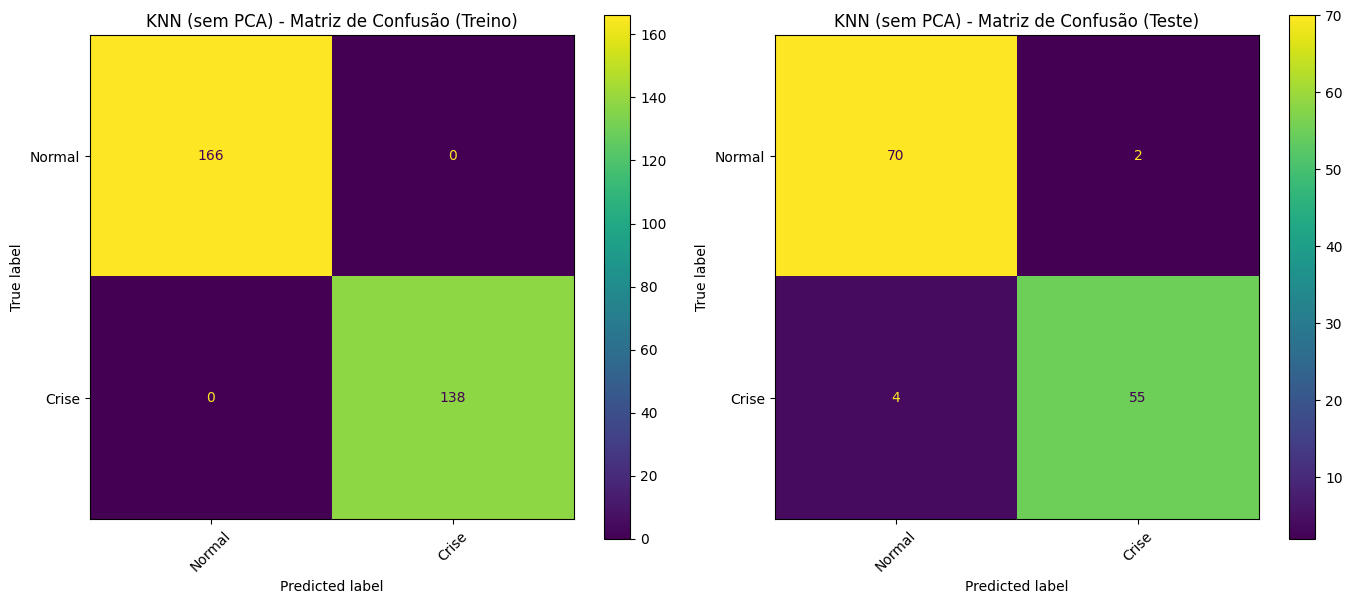

Melhores parâmetros (PCA):
{'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'}

===== KNN (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       166
       Crise       1.00      1.00      1.00       138

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.86      0.94      0.90        72
       Crise       0.92      0.81      0.86        59

    accuracy                           0.89       131
   macro avg       0.89      0.88      0.88       131
weighted avg       0.89      0.89      0.88       131



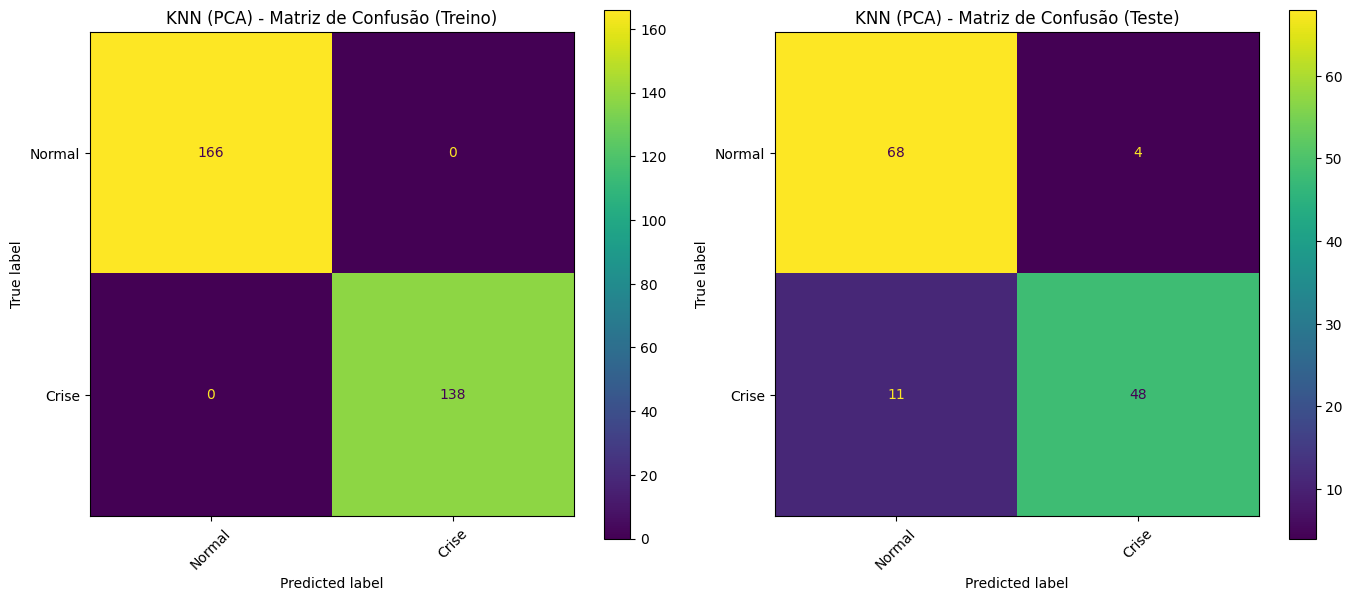

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ===== PIPELINE =====
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# ===== GRID =====
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_knn_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_knn_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="KNN (sem PCA)"
)

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_knn_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_knn_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="KNN (PCA)"
)

Voting Classifier


===== Voting Ensemble (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       166
       Crise       0.99      0.99      0.99       138

    accuracy                           0.99       304
   macro avg       0.99      0.99      0.99       304
weighted avg       0.99      0.99      0.99       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97        72
       Crise       0.97      0.95      0.96        59

    accuracy                           0.96       131
   macro avg       0.96      0.96      0.96       131
weighted avg       0.96      0.96      0.96       131



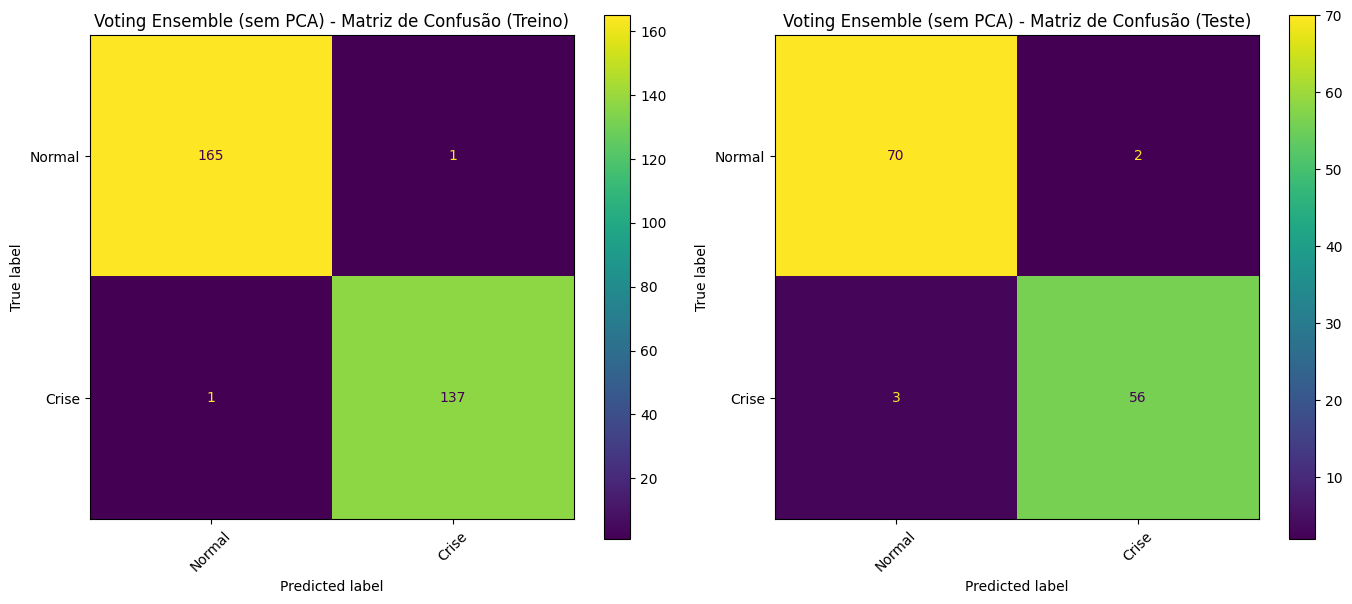


===== Voting Ensemble (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       166
       Crise       0.96      0.92      0.94       138

    accuracy                           0.95       304
   macro avg       0.95      0.95      0.95       304
weighted avg       0.95      0.95      0.95       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.81      0.92      0.86        72
       Crise       0.88      0.75      0.81        59

    accuracy                           0.84       131
   macro avg       0.85      0.83      0.84       131
weighted avg       0.84      0.84      0.84       131



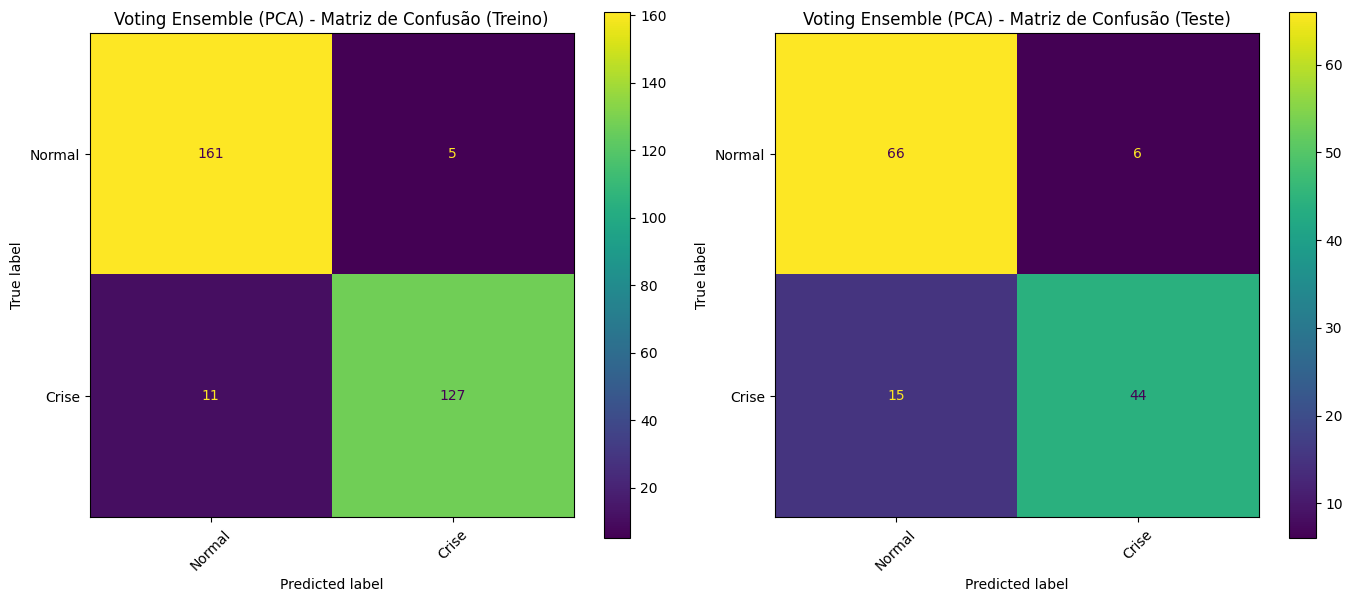

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== MODELOS BASE =====
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

# ===== VOTING SEM PCA =====
voting_no_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_no_pca.fit(X_train_no_pca, y_train_no_pca)

avaliar_modelo(
    voting_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Voting Ensemble (sem PCA)"
)

# ===== VOTING COM PCA =====
voting_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_pca.fit(X_train_pca, y_train_pca)

avaliar_modelo(
    voting_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Voting Ensemble (PCA)"
)

Random Forest

Melhores parâmetros (sem PCA):
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

===== Random Forest (sem PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       166
       Crise       1.00      1.00      1.00       138

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97        72
       Crise       0.98      0.95      0.97        59

    accuracy                           0.97       131
   macro avg       0.97      0.97      0.97       131
weighted avg       0.97      0.97      0.97       131



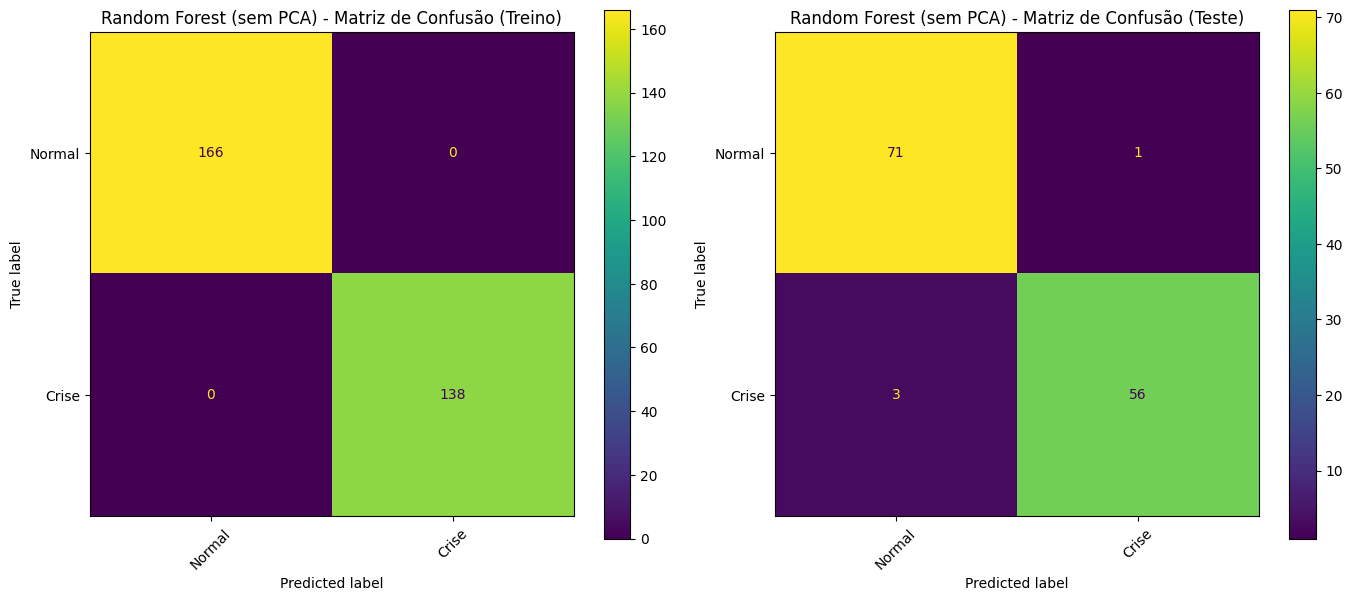


Importância das variáveis (sem PCA):
                 feature  importance
4       volatility_index    0.277014
2            price_index    0.264081
1  industrial_production    0.129684
3          real_interest    0.123851
5      yield_curve_slope    0.111117
0          credit_spread    0.094253


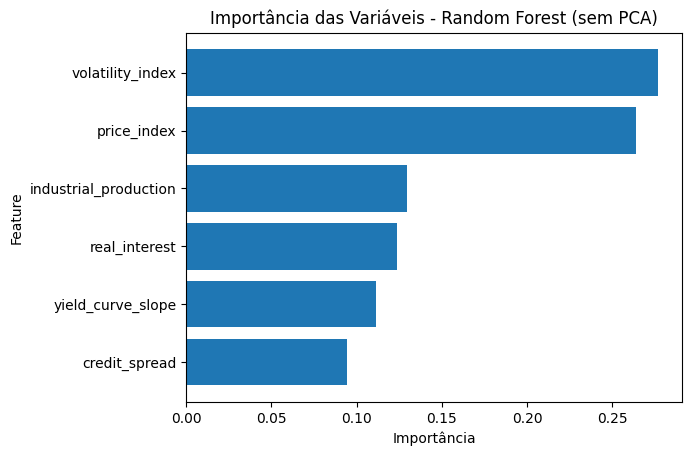

Melhores parâmetros (PCA):
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

===== Random Forest (PCA) =====

--- TREINO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       166
       Crise       1.00      1.00      1.00       138

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304


--- TESTE ---
              precision    recall  f1-score   support

      Normal       0.84      0.90      0.87        72
       Crise       0.87      0.80      0.83        59

    accuracy                           0.85       131
   macro avg       0.86      0.85      0.85       131
weighted avg       0.86      0.85      0.85       131



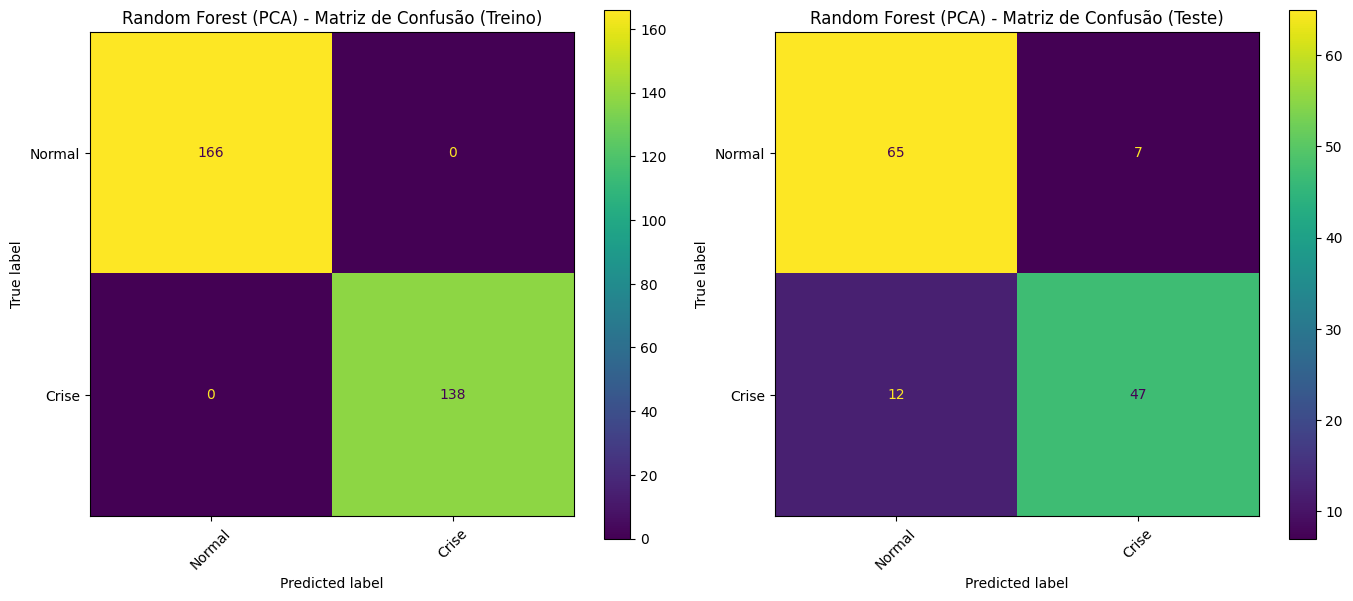


Importância das componentes PCA:
  feature  importance
2   pca_3    0.414127
1   pca_2    0.304966
0   pca_1    0.280907


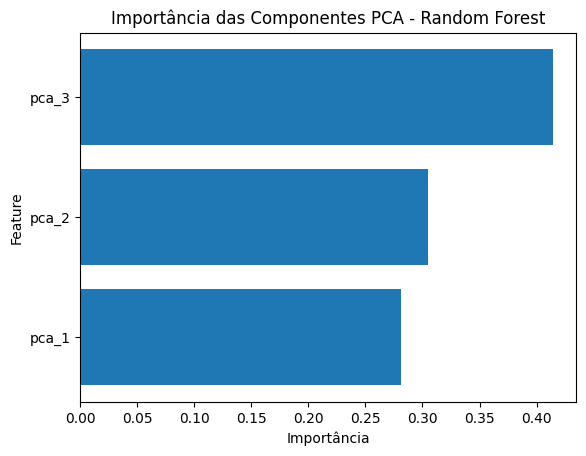

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# ===== MODELO BASE =====
rf = RandomForestClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_rf_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_rf_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Random Forest (sem PCA)"
)

importances = best_rf_no_pca.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportância das variáveis (sem PCA):")
print(df_importance)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest (sem PCA)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_rf_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_rf_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Random Forest (PCA)"
)

importances_pca = best_rf_pca.feature_importances_

df_importance_pca = pd.DataFrame({
    "feature": ["pca_1", "pca_2", "pca_3"],
    "importance": importances_pca
}).sort_values(by="importance", ascending=False)

print("\nImportância das componentes PCA:")
print(df_importance_pca)

plt.figure()
plt.barh(df_importance_pca["feature"], df_importance_pca["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Componentes PCA - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

Comparação Final

                           accuracy  precision    recall  f1_macro
modelo                                                            
Decision Tree (sem PCA)    0.938931   0.945694  0.933734  0.937619
Decision Tree (PCA)        0.748092   0.746994  0.741761  0.743244
KNN (sem PCA)              0.954198   0.955429  0.952213  0.953590
KNN (PCA)                  0.885496   0.891918  0.879002  0.882764
Voting Ensemble (sem PCA)  0.961832   0.962211  0.960687  0.961391
Voting Ensemble (PCA)      0.839695   0.847407  0.831215  0.835042
Random Forest (sem PCA)    0.969466   0.970958  0.967632  0.969060
Random Forest (PCA)        0.854962   0.857263  0.849694  0.852171


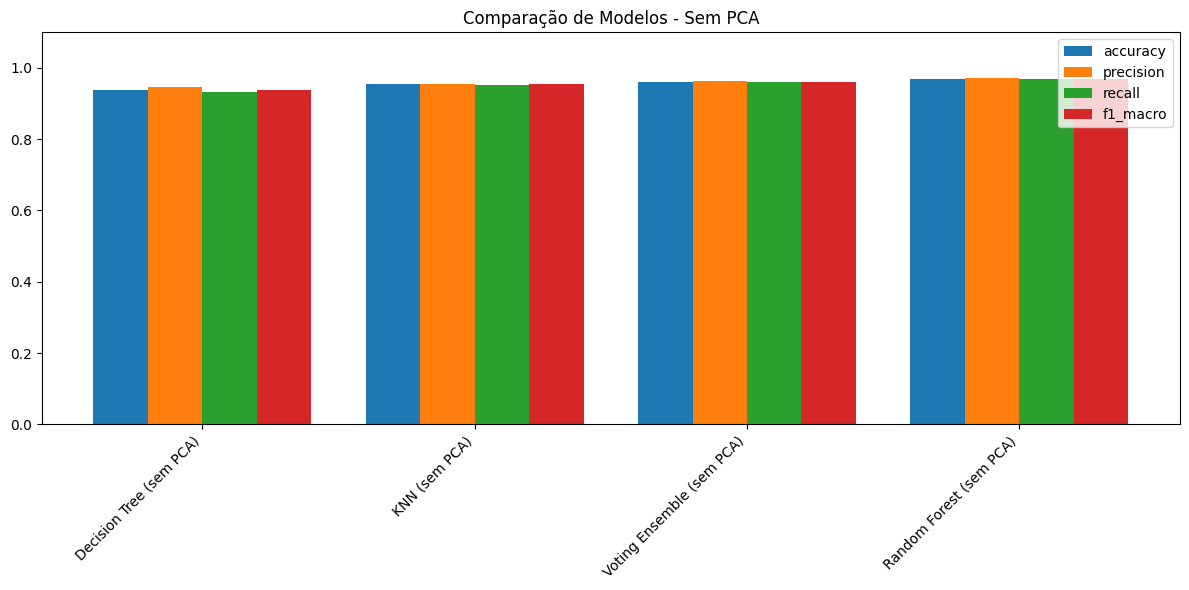

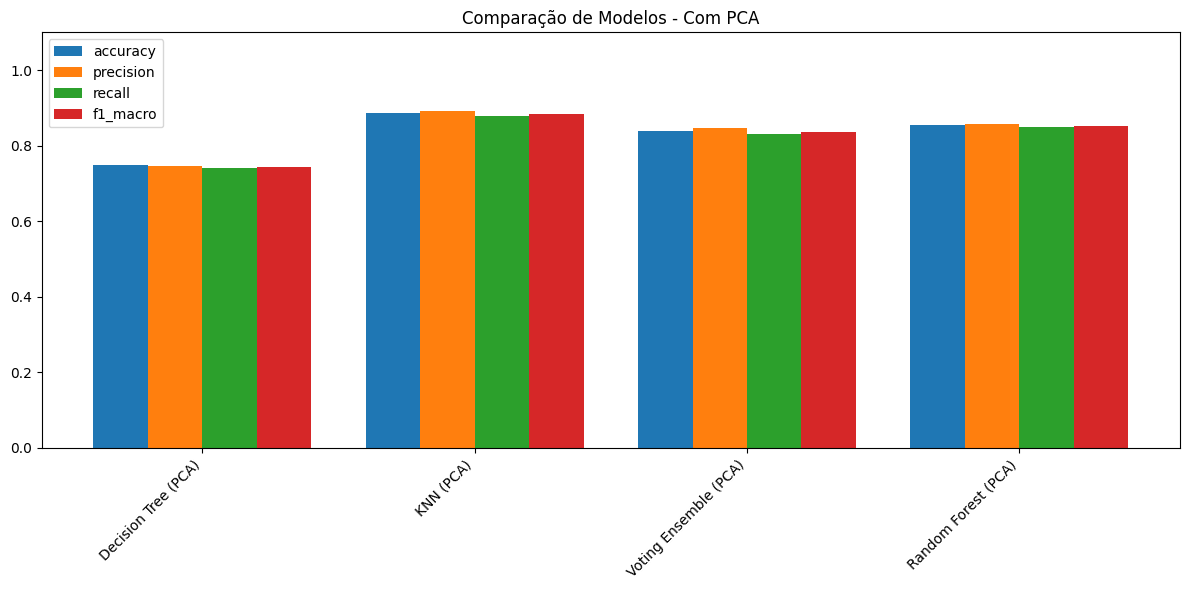

In [34]:
import numpy as np
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados).set_index("modelo")
print(df_resultados)

metricas = ["accuracy", "precision", "recall", "f1_macro"]
width = 0.2

# SEM PCA
modelos_sem_pca = [m for m in df_resultados.index if "sem PCA" in m]
df_sem_pca = df_resultados.loc[modelos_sem_pca]
x = np.arange(len(df_sem_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_sem_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_sem_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Sem PCA")
ax.legend()
plt.tight_layout()
plt.show()

# COM PCA
modelos_com_pca = [m for m in df_resultados.index if "sem PCA" not in m]
df_com_pca = df_resultados.loc[modelos_com_pca]
x = np.arange(len(df_com_pca))

fig, ax = plt.subplots(figsize=(12, 6))
for i, metrica in enumerate(metricas):
    ax.bar(x + i * width, df_com_pca[metrica], width, label=metrica)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_com_pca.index, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("Comparação de Modelos - Com PCA")
ax.legend()
plt.tight_layout()
plt.show()